#CUSTOMER CHURN PREDICTION

##IMPORTING REQUIRED LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, auc)
from xgboost import XGBClassifier
import plotly.graph_objects as go
import plotly.express as px


##DATA LOADING & EXPLORATION

In [ ]:
# Load the dataset
Customer_df = pd.read_csv('/content/customer_churn_dataset.csv')
Customer_df.head()

,Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
0,1,56,0,275,2,3,0
1,2,69,0,381,8,1,0
2,3,46,1,219,5,2,0
3,4,32,1,58,2,2,0
4,5,60,1,89,4,4,0


In [ ]:
Customer_df.shape

(1000, 7)

In [ ]:
Customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer_ID           1000 non-null   int64
 1   Age                   1000 non-null   int64
 2   Gender                1000 non-null   int64
 3   Monthly_Spending      1000 non-null   int64
 4   Subscription_Length   1000 non-null   int64
 5   Support_Interactions  1000 non-null   int64
 6   Churn                 1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


In [ ]:
Customer_df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Monthly_Spending,0
Subscription_Length,0
Support_Interactions,0
Churn,0


Our data is super clean.

In [ ]:
Customer_df['Churn'].value_counts()

,count
Churn,
0,758
1,242


In [ ]:
churn_rate = (Customer_df['Churn'].sum() / len(Customer_df)) * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 24.20%


In [ ]:
Customer_df.describe()

,Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.385000,0.476000,275.791000,4.973000,1.959000,0.242000
std,288.819436,15.321669,0.499674,131.061193,2.555152,1.435053,0.428509
min,1.000000,18.000000,0.000000,50.000000,1.000000,0.000000,0.000000
25%,250.750000,31.750000,0.000000,166.000000,3.000000,1.000000,0.000000
50%,500.500000,45.000000,0.000000,278.000000,5.000000,2.000000,0.000000
75%,750.250000,57.000000,1.000000,387.250000,7.000000,3.000000,0.000000
max,1000.000000,70.000000,1.000000,500.000000,9.000000,4.000000,1.000000


## DATA VISUALIZATIONS

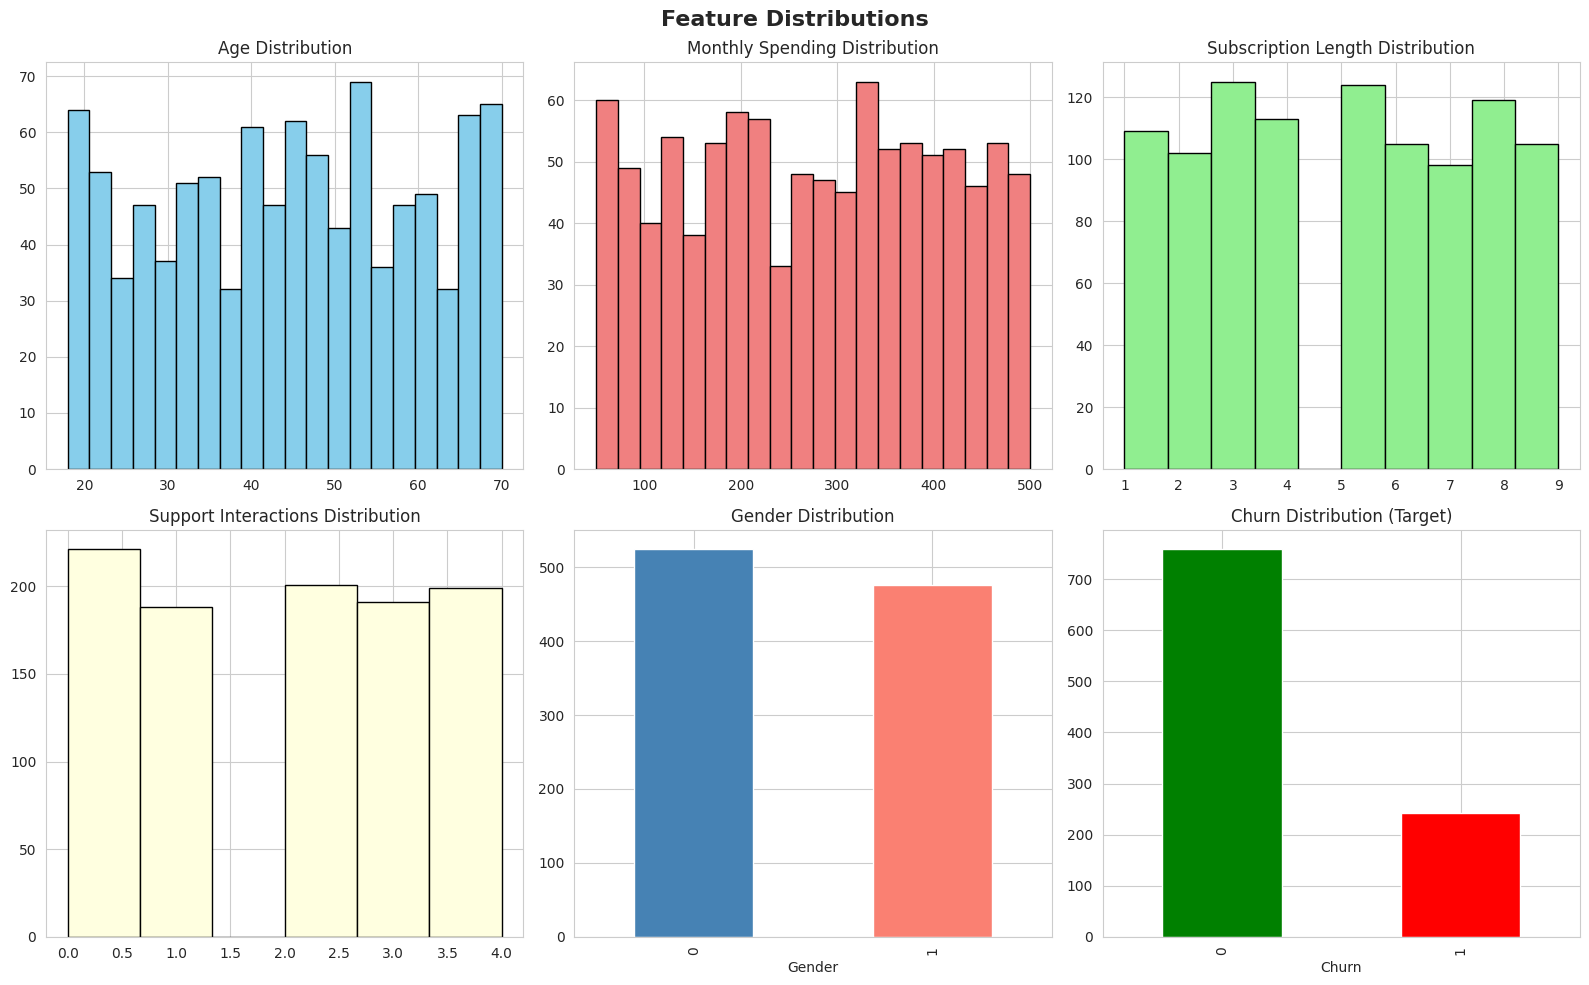

In [ ]:
# Visualize feature distributions
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

Customer_df['Age'].hist(ax=axes[0, 0], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')

Customer_df['Monthly_Spending'].hist(ax=axes[0, 1], bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Monthly Spending Distribution')

Customer_df['Subscription_Length'].hist(ax=axes[0, 2], bins=10, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Subscription Length Distribution')

Customer_df['Support_Interactions'].hist(ax=axes[1, 0], bins=6, color='lightyellow', edgecolor='black')
axes[1, 0].set_title('Support Interactions Distribution')

Customer_df['Gender'].value_counts().plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'salmon'])
axes[1, 1].set_title('Gender Distribution')

Customer_df['Churn'].value_counts().plot(kind='bar', ax=axes[1, 2], color=['green', 'red'])
axes[1, 2].set_title('Churn Distribution (Target)')

plt.tight_layout()
plt.show()

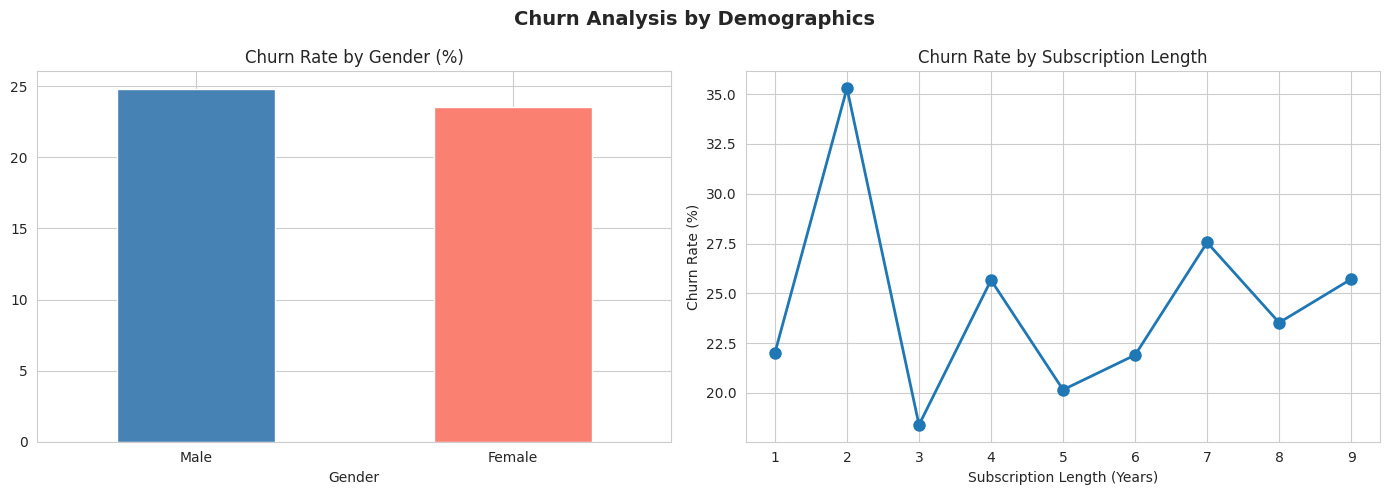

In [ ]:
# Churn analysis by demographics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Analysis by Demographics', fontsize=14, fontweight='bold')

gender_churn = Customer_df.groupby('Gender')['Churn'].apply(lambda x: (x.sum() / len(x)) * 100)
gender_churn.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Churn Rate by Gender (%)')
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)

subscription_churn = Customer_df.groupby('Subscription_Length')['Churn'].apply(lambda x: (x.sum() / len(x)) * 100)
subscription_churn.plot(kind='line', marker='o', ax=axes[1], linewidth=2, markersize=8)
axes[1].set_title('Churn Rate by Subscription Length')
axes[1].set_xlabel('Subscription Length (Years)')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

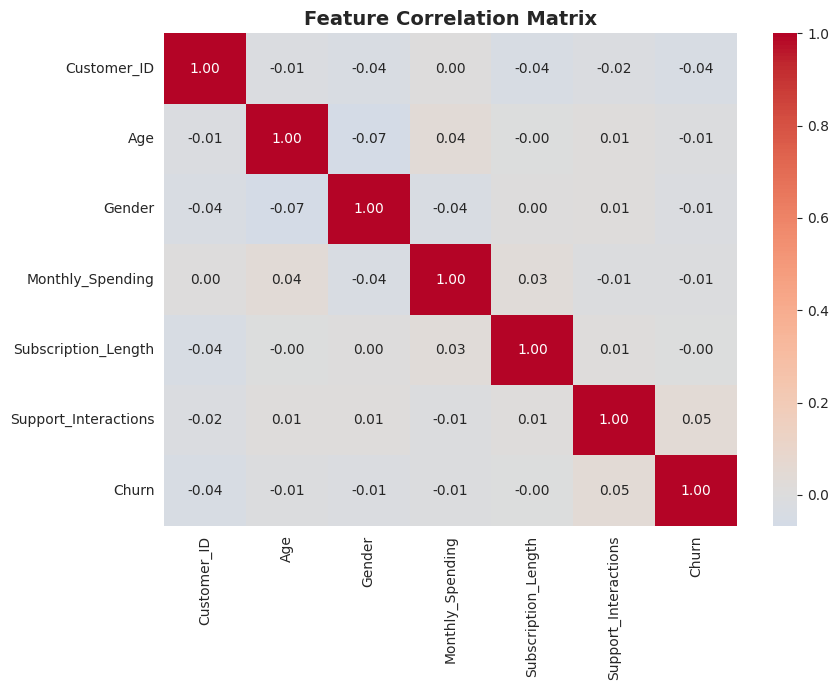

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
correlation_matrix = Customer_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## DATA PREPROCESSING

In [ ]:
Customer_df_clean = Customer_df.copy()

# Drop Customer_ID column (not needed for modeling)
Customer_df_clean = Customer_df_clean.drop('Customer_ID', axis=1)

In [ ]:
# Separate features and target
X = Customer_df_clean.drop('Churn', axis=1)
y = Customer_df_clean['Churn']

X,y

(     Age  Gender  Monthly_Spending  Subscription_Length  Support_Interactions
 0     56       0               275                    2                     3
 1     69       0               381                    8                     1
 2     46       1               219                    5                     2
 3     32       1                58                    2                     2
 4     60       1                89                    4                     4
 ..   ...     ...               ...                  ...                   ...
 995   25       1               474                    2                     1
 996   66       0               439                    6                     3
 997   52       0                74                    2                     1
 998   69       0               190                    2                     4
 999   32       0               166                    8                     4
 
 [1000 rows x 5 columns],
 0      0
 1      0
 2  

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.shape

(800, 5)

In [ ]:
X_test.shape

(200, 5)

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##MODEL TRAINING

In [ ]:
# Train models
models = {}
results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
models['Logistic Regression'] = lr
results['Logistic Regression'] = {'pred': lr_pred, 'prob': lr_prob}

# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
models['Random Forest'] = rf
results['Random Forest'] = {'pred': rf_pred, 'prob': rf_prob}

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
models['Gradient Boosting'] = gb
results['Gradient Boosting'] = {'pred': gb_pred, 'prob': gb_prob}

# XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42,
                    use_label_encoder=False, eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
models['XGBoost'] = xgb
results['XGBoost'] = {'pred': xgb_pred, 'prob': xgb_prob}

# Model evaluation
eval_data = []

for name, result in results.items():
    acc = accuracy_score(y_test, result['pred'])
    prec = precision_score(y_test, result['pred'], zero_division=0)
    rec = recall_score(y_test, result['pred'], zero_division=0)
    f1 = f1_score(y_test, result['pred'], zero_division=0)
    auc_score = roc_auc_score(y_test, result['prob'])

    eval_data.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc_score, 4)
    })

eval_df = pd.DataFrame(eval_data)

print("\nModel Performance Comparison:")
eval_df


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.76,0.0000,0.0000,0.0000,0.5252
1,Random Forest,0.76,0.5000,0.0417,0.0769,0.6027
2,Gradient Boosting,0.73,0.3333,0.1250,0.1818,0.5791
3,XGBoost,0.73,0.2500,0.0625,0.1000,0.5714


## FINDING BEST MODEL

In [ ]:
# Find best model
best_idx = eval_df['F1-Score'].idxmax()
best_name = eval_df.loc[best_idx, 'Model']
best_model = models[best_name]
best_pred = results[best_name]['pred']
best_prob = results[best_name]['prob']

print(f"\nBest Model: {best_name}")
print(f"F1-Score: {eval_df.loc[best_idx, 'F1-Score']}")


Best Model: Gradient Boosting
F1-Score: 0.1818


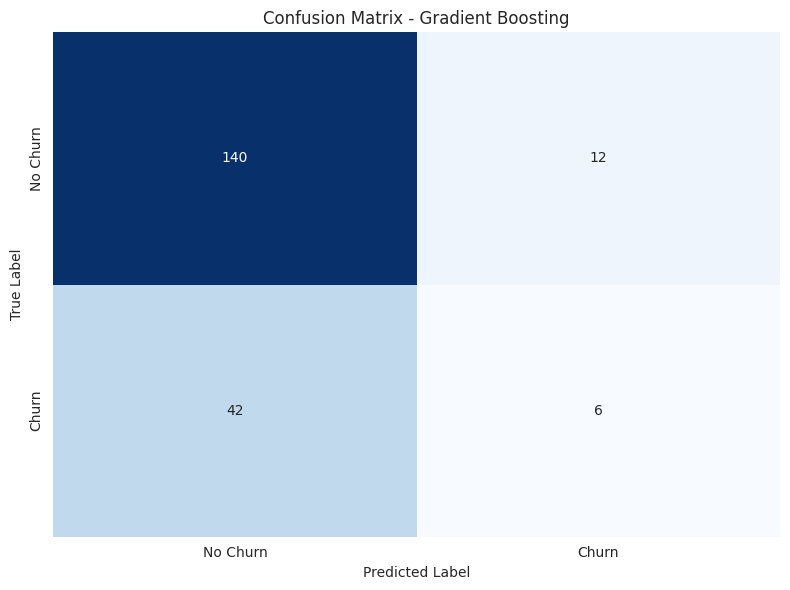

In [ ]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

In [ ]:
# Classification report
print(f"\nClassification Report ({best_name}):")
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn'], digits=4))


Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

    No Churn     0.7692    0.9211    0.8383       152
       Churn     0.3333    0.1250    0.1818        48

    accuracy                         0.7300       200
   macro avg     0.5513    0.5230    0.5101       200
weighted avg     0.6646    0.7300    0.6808       200



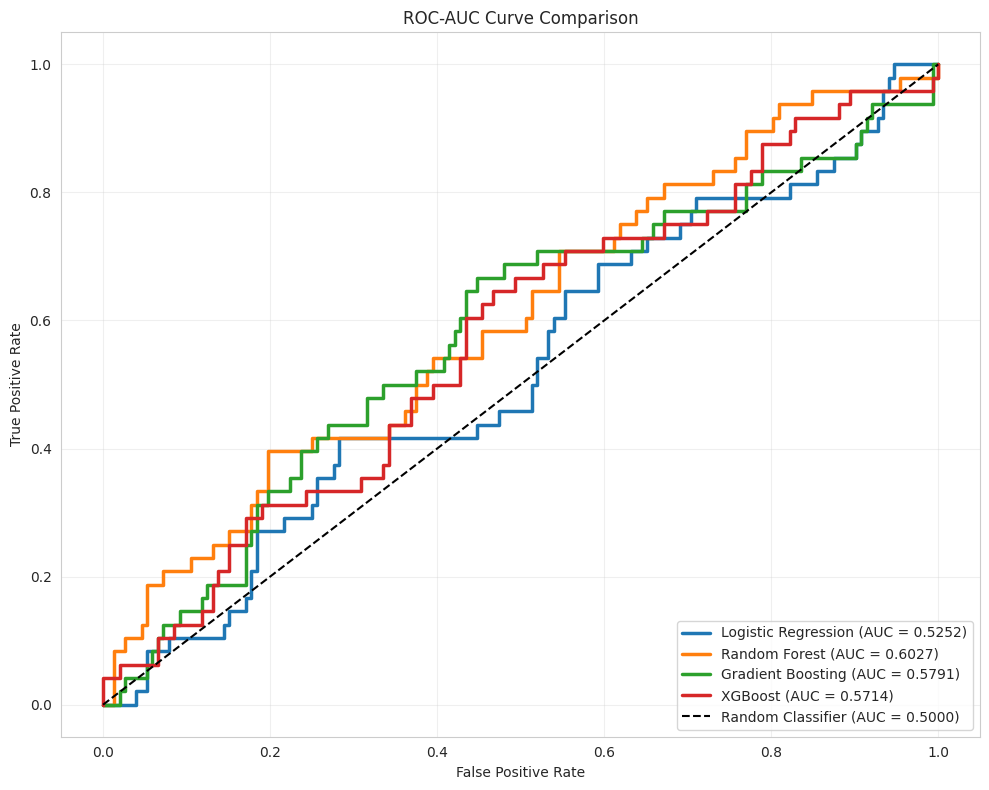

In [ ]:
# ROC-AUC curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC Curve Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Feature Importance (Gradient Boosting):
             Feature  Importance
    Monthly_Spending    0.475637
                 Age    0.265925
 Subscription_Length    0.133821
Support_Interactions    0.086245
              Gender    0.038372


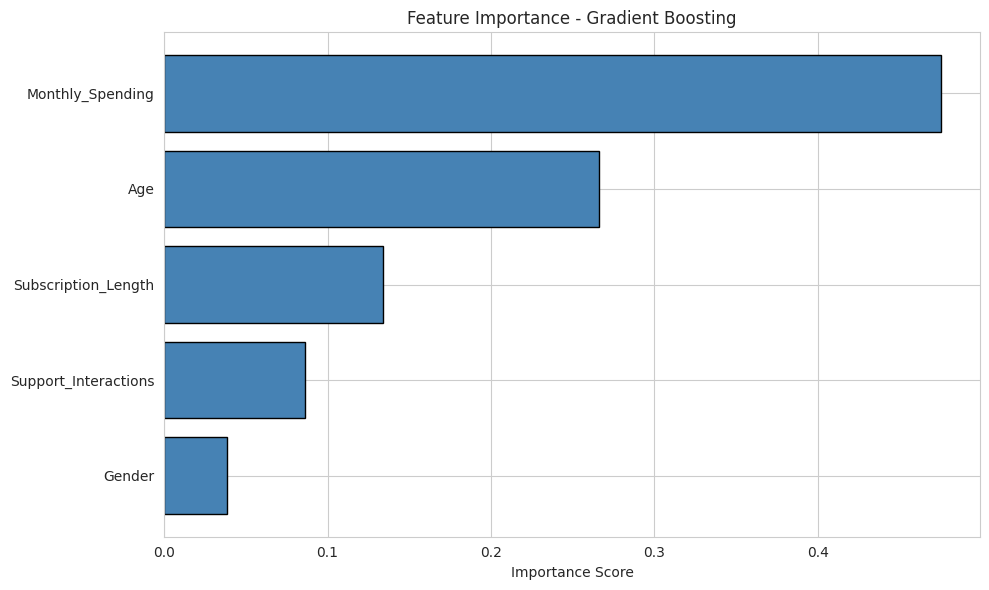

In [ ]:
# Feature importance (for tree-based models)
if best_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    importance = best_model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    print(f"\nFeature Importance ({best_name}):")
    print(importance_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance - {best_name}')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## SAMPLE PREDICTION AND COMPARING RESULTS

In [ ]:
# Show sample predictions
pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_pred,
    'Probability': best_prob,
    'Correct': y_test.values == best_pred
})

pred_df['Actual'] = pred_df['Actual'].map({0: 'No Churn', 1: 'Churn'})
pred_df['Predicted'] = pred_df['Predicted'].map({0: 'No Churn', 1: 'Churn'})
pred_df['Probability'] = pred_df['Probability'].apply(lambda x: f'{x:.4f}')
pred_df['Correct'] = pred_df['Correct'].map({True: 'Yes', False: 'No'})

print("\nFirst 15 Predictions:")
print(pred_df.head(15).to_string(index=False))


First 15 Predictions:
  Actual Predicted Probability Correct
No Churn  No Churn      0.1311     Yes
   Churn     Churn      0.5090     Yes
   Churn  No Churn      0.3330      No
   Churn  No Churn      0.2999      No
No Churn  No Churn      0.0470     Yes
No Churn  No Churn      0.4638     Yes
   Churn  No Churn      0.2563      No
   Churn  No Churn      0.0239      No
No Churn  No Churn      0.2483     Yes
No Churn  No Churn      0.1303     Yes
No Churn  No Churn      0.0292     Yes
No Churn  No Churn      0.1285     Yes
   Churn  No Churn      0.1732      No
   Churn  No Churn      0.3464      No
No Churn     Churn      0.5012      No
